# Purpose

Simulate GO terms whose membership is restricted accoreding to Gini indexes

As our primary example, I will simulte GO terms according to brain cell type profile derived gini indexes

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# path = "../MGC/data/brain_gini.csv"


# Stratify genes according to Gini score. Simulate tissue GOs


In [16]:
def stratify(ranked):
	"""Stratify genes into 10 bins according to their ranked indexes
	"""
	# St based on 'mgc_ranked' column
	ranked = ranked.sort_values('score', ascending=False)
	n = 300
	q_top = ranked.head(n)
	q_bot = ranked.tail(n)
	q_mid = ranked.iloc[n:-n]  # excludes top and bottom 10%

	q_top["Q"]=3
	q_mid["Q"]=2
	q_bot["Q"]=1
	return [q_bot, q_mid, q_top]


def create_go_term(i, df):
	"""Create 1 GO term by sampling genes from df

	Args:
		i (int): stratification level we are sampling from
		df (_type_): colntains genes from strat level
	"""
	go = df.sample(30) # number of genes contained in new go term
	go['GOID'] = f"SIMGO_{i}"
	go = go.loc[:,['gene','GOID', 'score']]
	return go

def simulate_quartile_go_terms(q_df):
	lo_go_terms = []

	for i  in range(1,1000): # how many GO terms we want to simulate
		go_term = create_go_term(i, q_df)
		lo_go_terms.append(go_term)
	return pd.concat(lo_go_terms, axis = 0)
	
	
def sim(lo_dfs):
	"""simulate GO terms that only contain genes of a specific subset of ranked indexes

	Args:
		lo_dfs (List): List of dfs where each df contains genes we want to sample from to create a GO term

	Returns:
		pd.DataFrame: contains simulatded GO terms and gene membership
	"""
	lo_qs = []
	for i, q_df in enumerate(lo_dfs):
		
		df = simulate_quartile_go_terms(q_df)
		df['GO.ID'] = df['GOID'].astype(str) + "_Q" +str(i+1)
		df['Q']=i+1
		lo_qs.append(df)
	df = pd.concat(lo_qs, axis = 0)
	df.reset_index(drop=True, inplace=True)
	df.rename(columns={'gene':'ensembl_gene_id'}, inplace=True)
	return df

# path = "../../../MGC/data/gini_brain.csv"
# gini = pd.read_csv(path, index_col=0)
# gini
# sims = sim(lo_dfs=lo_dfs)
# sims.to_csv("data/simulatedGOs_brain.csv", index=None)
# sims

In [19]:
def __main__(path_to_rankeds, save_path):
	ranked = pd.read_csv(path_to_rankeds)
	ranked.columns = ['gene','score']
	# stratify genes
	lo_dfs = stratify(ranked)
	# sim go terms
	sims = sim(lo_dfs=lo_dfs)
	# save
	sims.to_csv(save_path, index=None)
	return sims

sims = __main__('../../../MGC/data/gini_brain.csv', 'data/simulated_brain_GOs.csv')

/tmp/ipykernel_3640109/2992685137.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q_top["Q"]=3
/tmp/ipykernel_3640109/2992685137.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q_mid["Q"]=2
/tmp/ipykernel_3640109/2992685137.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vi

### sanity check

Here we can see that the gini indexes and MGC scores of the GO terms we've created increase with Q

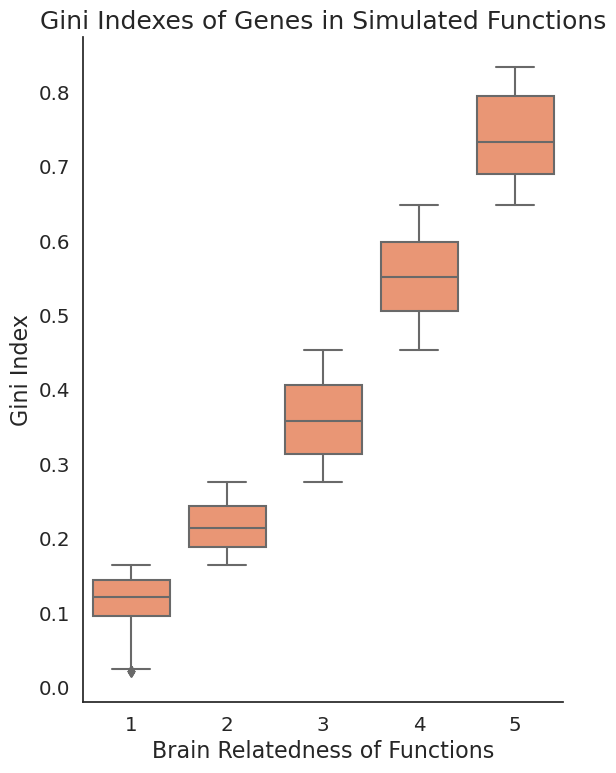

In [ ]:

# Set white background and increase base font size
sns.set(style="white", palette="pastel", font_scale=1.3)
set2_colors = sns.color_palette("Set2")
# Set figure size
plt.figure(figsize=(6, 8))

# Create the boxplot
sns.boxplot(data=sims, y='gini', x='Q', color=set2_colors[1])

# Add title and axis labels
plt.title("Gini Indexes of Genes in Simulated Functions", fontsize=18)
plt.xlabel("Brain Relatedness of Functions", fontsize=16)
plt.ylabel("Gini Index", fontsize=16)

# Remove top and right spines for a cleaner look
sns.despine()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.savefig('figs/brain_ginis.png', dpi = 300)
plt.savefig('figs/brain_ginis.svg', dpi = 300)
plt.show()

Text(0.5, 1.0, 'MGCs of simulated GO terms')

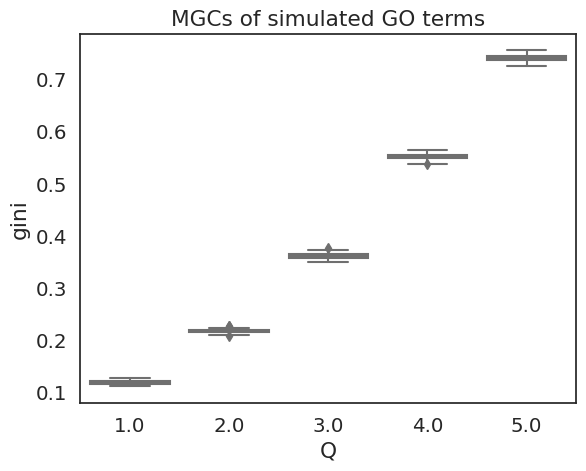

In [ ]:
sns.boxplot(sims.groupby("GO.ID")[['gini', "Q"]].mean(), y = 'gini', x = 'Q')
plt.title("MGCs of simulated GO terms")

# Wrapper function to simulate GO terms

In [ ]:
def __main__(path_to_ginis, save_path):
	gini = pd.read_csv(path_to_ginis)
	print(gini)
	# stratify genes
	lo_dfs = stratify(gini)
	# sim go terms
	sims = sim(lo_dfs=lo_dfs)
	# save
	sims.to_csv(save_path)


In [ ]:
# simulate PBMC-gini derived GO Terms
__main__(path_to_ginis="../MGC/data/gini_pbmc.csv", save_path='data/simulatedGOs_PBMC.csv')

            Unnamed: 0      gini
0      ENSG00000000003  0.857143
1      ENSG00000000419  0.163644
2      ENSG00000000457  0.460685
3      ENSG00000000460  0.630479
4      ENSG00000000938  0.538089
...                ...       ...
13434  ENSG00000286264  0.857143
13435  ENSG00000288558  0.429803
13436  ENSG00000288602  0.766817
13437  ENSG00000288675  0.553765
13438  ENSG00000288695  0.627905

[13439 rows x 2 columns]


In [ ]:
# simulate all-cell-type-profile-gini derived GO terms
__main__(path_to_ginis="../MGC/data/gini_all.csv", save_path='data/simulatedGOs_all.csv')

            Unnamed: 0      gini
0      ENSG00000000003  0.614077
1      ENSG00000000005  0.933470
2      ENSG00000000419  0.339959
3      ENSG00000000457  0.371590
4      ENSG00000000460  0.660531
...                ...       ...
19432  ENSG00000288658  0.835362
19433  ENSG00000288675  0.694484
19434  ENSG00000288681  0.972263
19435  ENSG00000288684  0.809557
19436  ENSG00000288695  0.870953

[19437 rows x 2 columns]
